# Experiment 2 (MNIST): Lipschitz Estimation on Real Classifiers

## Motivation and relation to Experiment 1

Experiment 1 (`toy_lipschitz`, sibling folder) built three ways to estimate
a function's **Lipschitz constant** `L` -- how much its output can change
for a given change in input, `|f(x')-f(x)| <= L * ||x'-x||` -- and
validated all three against a **known, closed-form ground truth** `L*` on
a toy 1D/2D regression problem. It also showed that replacing plain
Euclidean distance with a **Mahalanobis distance** fit from the data
itself can substantially change (and, there, improve) the resulting
estimate.

This experiment scales the same three estimators up to real classifiers
trained on MNIST. **There is no closed-form `L*` here** -- a trained
neural network's exact Lipschitz constant is not analytically knowable in
general. So this experiment cannot ask "how close is the estimate to the
truth"; it can only ask two weaker but still meaningful questions:

1. **Do the three independent sub-methods (pairwise, local-perturbation,
   gradient-norm) roughly agree with each other?** Disagreement doesn't
   necessarily mean a bug (see this notebook's results below -- it turns
   out they *don't* agree well here, and that's a real, reportable
   finding, not an error), but it tells you how much to trust any single
   number.
2. **Is the estimate stable under resampling?** An estimate that swings
   wildly depending on which random subset of the data it was computed
   from is fitting sampling noise, not a real property of the model.

These two checks -- sub-method agreement and subsample stability --
replace Experiment 1's "compare to `L*`" checkpoint everywhere in this
notebook.

**Out of scope for this experiment** (may return in a later one):
adversarial examples, FGSM/PGD attacks, robustness mitigations (weight
decay, spectral norm, gradient penalty, adversarial training, input
smoothing), Fashion-MNIST.

## What's being measured

Instead of a scalar regression output `f(x)` (Experiment 1), a classifier
outputs 10 logits. The Lipschitz estimators here are applied to the
**margin function**, `margin(x) = logit[y_true] - max(logit[j] for j !=
y_true)` -- the natural classifier analogue of a scalar output, and the
quantity robustness actually depends on: the margin crossing zero is
exactly where the predicted class flips.

Three classifiers are trained (logistic regression, a small MLP, a small
CNN), and for each, all three sub-methods are computed twice: once under
plain Euclidean distance, once under a **ridge-regularized Mahalanobis
distance** fit from MNIST's own pixel covariance (raw pixel covariance is
exactly singular -- many border pixels are 0 in every image -- so it must
be regularized before it can be inverted; how much regularization to use
is itself selected by a data-driven sweep, mirroring Experiment 1's
polynomial-embedding-degree selection).

This is a thin driver notebook -- all reusable logic lives in the sibling
`.py` modules (`data.py`, `models.py`, `estimators.py`, `distance.py`,
`run_experiment.py`, `plots.py`); this notebook only calls into them and
displays the results. See `README.md` in this folder for a plain
file-by-file reference of the codebase and the full write-up of what was
found.

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from mnist_lipschitz import run_experiment, plots

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Running the full experiment

`run_mnist_experiment()` runs, in order:

1. **Train** logistic regression, MLP, and a small CNN on full MNIST.
2. **Euclidean-distance estimates**: all three sub-methods (pairwise,
   local-perturbation, gradient-norm), on all three models, evaluated on a
   fixed set of held-out test points.
3. **Epsilon selection**: fit the full-training-set pixel covariance,
   sweep several candidate ridge strengths (`epsilon`), and pick the
   smallest one whose regularized covariance is well-conditioned *and*
   whose resulting estimate is stable across independent random
   subsamples of the training data.
4. **Mahalanobis-distance estimates**: the same three sub-methods on the
   same three models, now under the selected Mahalanobis distance.
5. **Save** everything to `results/` (`mnist_experiment_results.json` for
   scalar summaries, `mnist_experiment_arrays.npz` for the full per-point
   arrays).

This takes about a minute on CPU.

In [6]:
results = run_experiment.run_mnist_experiment()

=== Step 1: training models ===
  epoch  1/15  train loss 0.8430
  epoch  2/15  train loss 0.4254
  epoch  3/15  train loss 0.3603
  epoch  4/15  train loss 0.3299
  epoch  5/15  train loss 0.3119
  epoch  6/15  train loss 0.2999
  epoch  7/15  train loss 0.2914
  epoch  8/15  train loss 0.2845
  epoch  9/15  train loss 0.2793
  epoch 10/15  train loss 0.2749
  epoch 11/15  train loss 0.2714
  epoch 12/15  train loss 0.2682
  epoch 13/15  train loss 0.2654
  epoch 14/15  train loss 0.2631
  epoch 15/15  train loss 0.2611
  epoch  1/15  train loss 0.5266
  epoch  2/15  train loss 0.2355
  epoch  3/15  train loss 0.1799
  epoch  4/15  train loss 0.1436
  epoch  5/15  train loss 0.1195
  epoch  6/15  train loss 0.1021
  epoch  7/15  train loss 0.0866
  epoch  8/15  train loss 0.0765
  epoch  9/15  train loss 0.0657
  epoch 10/15  train loss 0.0584
  epoch 11/15  train loss 0.0517
  epoch 12/15  train loss 0.0456
  epoch 13/15  train loss 0.0411
  epoch 14/15  train loss 0.0364
  epoch 15/

## Model accuracies

Sanity check before looking at any Lipschitz numbers: did training
actually work? (Thresholds validated in `tests/test_models.py`: logistic
regression > 90%, MLP > 96%, CNN > 98%, each with headroom below what's
typically observed.)

In [7]:
for name, acc in results["accuracies"].items():
    print(f"{name:20s} train_acc={acc['train']:.4f}  test_acc={acc['test']:.4f}")

logistic_regression  train_acc=0.9287  test_acc=0.9270
mlp                  train_acc=0.9931  test_acc=0.9782
cnn                  train_acc=0.9889  test_acc=0.9865


## Euclidean-distance estimates: do the three sub-methods agree?

Plain Euclidean distance in raw pixel space, for all three models. Each
panel below is one model; the three bars are the three independently
implemented sub-methods, on a log scale (they live on very different
natural scales here, which is itself part of the finding).

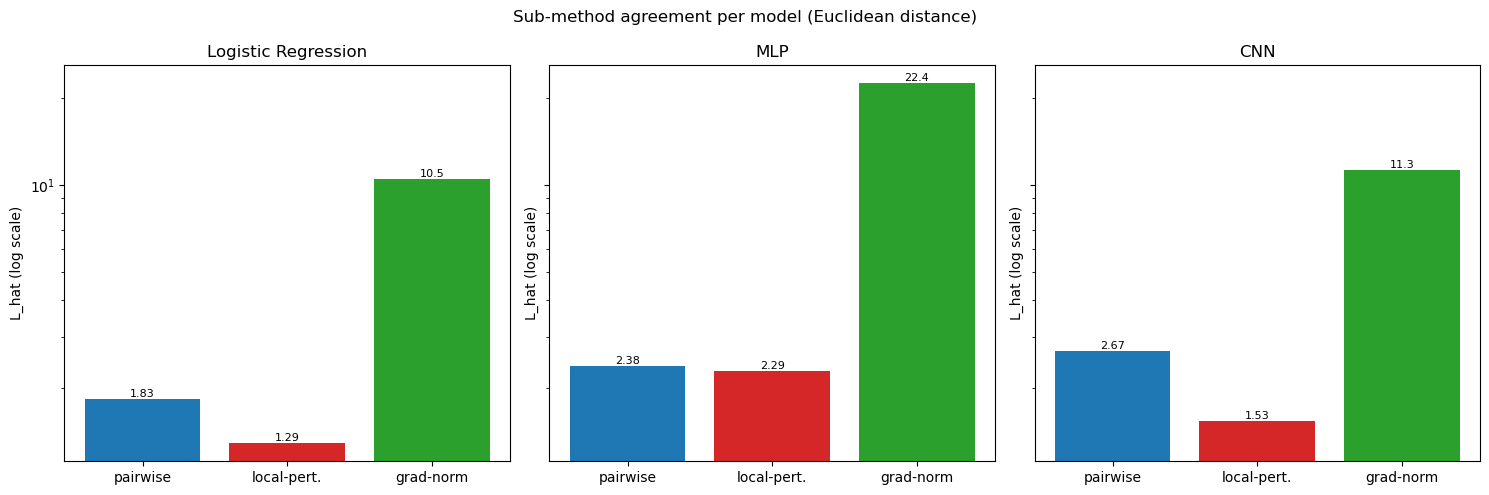

In [8]:
fig_agree_euclidean = plots.plot_submethod_agreement(
    results["euclidean_results"], metric_name="Euclidean",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_euclidean.png")
display(fig_agree_euclidean)

## Epsilon selection

MNIST's raw pixel covariance is exactly singular (constant-zero border
pixels), so it can't be inverted directly. The plot below shows, across a
range of candidate `epsilon` values (log scale): the condition number of
the ridge-regularized covariance (should shrink as epsilon grows -- always
true, this is a deterministic mathematical fact) and the coefficient of
variation of the resulting estimate across independent random subsamples
of the training set (should not get *worse* as epsilon grows -- this one
is an empirical check, not a mathematical guarantee, and is where a real
implementation bug would show up first). The selected epsilon (dashed
line) is the smallest one meeting both a condition-number bound and a
stability bound.

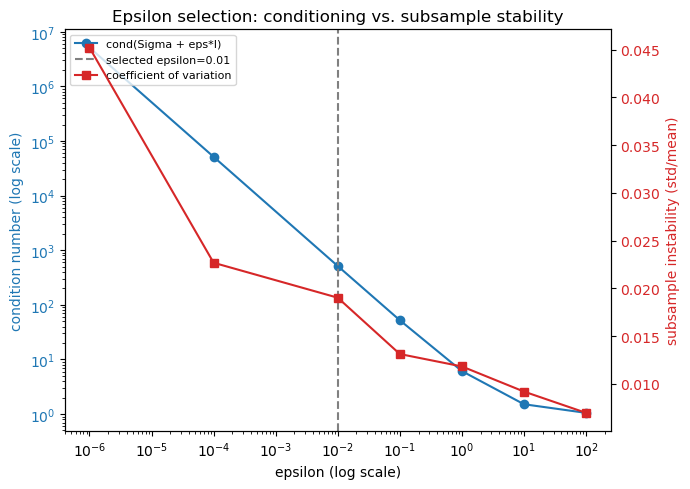

selected epsilon = 0.01


In [9]:
fig_epsilon = plots.plot_epsilon_sweep(
    results["epsilon_values"], results["cond_numbers"], results["cv_values"],
    selected_epsilon=results["selected_epsilon"],
    save_path=run_experiment.RESULTS_DIR / "epsilon_sweep.png")
display(fig_epsilon)
print(f"selected epsilon = {results['selected_epsilon']:g}")

## Mahalanobis vs. Euclidean: does the metric change the estimates?

This is the central question of the experiment -- the same question
Experiment 1 asked on the toy problem, now on real classifiers. Same
three models, same three sub-methods, only the distance metric changes.

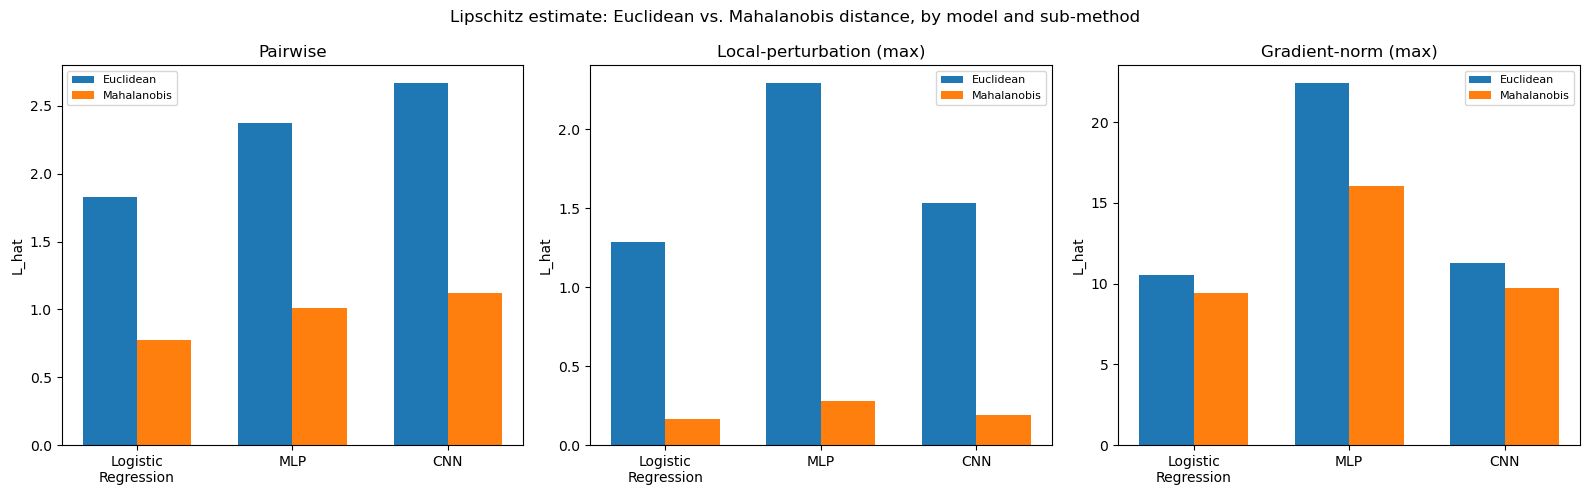

In [10]:
fig_compare = plots.plot_euclidean_vs_mahalanobis(
    results["euclidean_results"], results["mahalanobis_results"],
    save_path=run_experiment.RESULTS_DIR / "euclidean_vs_mahalanobis.png")
display(fig_compare)

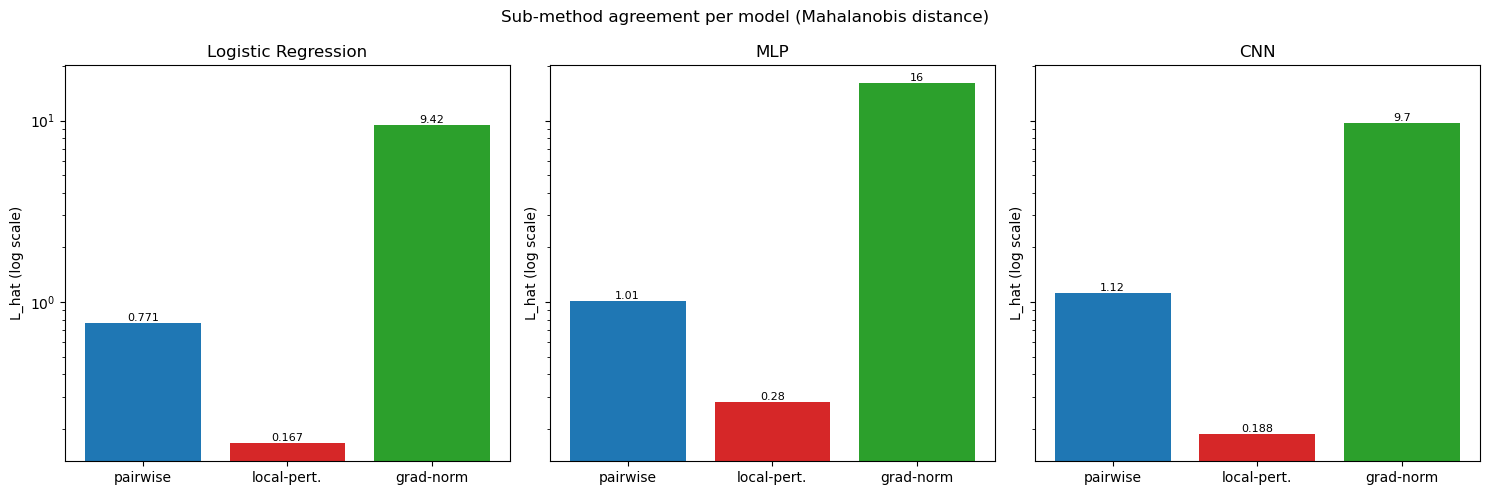

In [11]:
fig_agree_mahalanobis = plots.plot_submethod_agreement(
    results["mahalanobis_results"], metric_name="Mahalanobis",
    save_path=run_experiment.RESULTS_DIR / "submethod_agreement_mahalanobis.png")
display(fig_agree_mahalanobis)

## Ratio distribution and near-neighbour pairs

Every checkpoint above looks at a single summary number per model/metric
-- a max (`pairwise`), or a max/mean over a few hundred points. This
checkpoint instead looks at the full **distribution** of pairwise ratios,
`|margin_i - margin_j| / distance(x_i, x_j)`, computed over all pairs in
a **stratified sample** of 1000 test points (roughly 100 per digit, so no
class dominates by chance) that's disjoint from the 300-point sample used
above.

It then asks a more specific question: does that distribution look
different when restricted to **near-neighbour** pairs -- points that are
actually close together in raw pixel space (5-nearest-neighbours), rather
than arbitrary pairs of digits that may look nothing alike? This matters
because adversarial-style local stretch is a *local* phenomenon: the
ratio between two visually unrelated digits (a 1 and an 8 on opposite
sides of pixel space) says little about how sensitive the model is to a
*small* perturbation, whereas the ratio between two visually similar
images is closer to what a local Lipschitz constant is actually meant to
capture.

**This checkpoint is logistic regression + Euclidean distance only, for
now** -- matching the rest of this notebook's scope statement at the top.
Running the same analysis for the MLP, CNN, and the Mahalanobis distance
is a natural next extension (the underlying function,
`run_ratio_distribution_analysis`, already takes `model`/`distance_fn` as
parameters for exactly this reason), but hasn't been run yet.

In [12]:
# Reuses the result already computed inside run_mnist_experiment() above (Step 2b)
# rather than recomputing it -- run_ratio_distribution_analysis is directly callable
# with different model/distance_fn arguments when extending to MLP/CNN/Mahalanobis.
ratio_dist_results = results["ratio_dist_results"]

## Does the distribution shift near neighbours?

If near-neighbour pairs behave just like a random pair of digits, the two
distributions below should overlap almost exactly. If local stretch is
concentrated near visually similar images, the near-neighbour curve
should sit measurably to the right of (or otherwise diverge from) the
full distribution -- not necessarily a dramatic difference, but a
detectable one.

                             shape       min       max      mean    median       std
all pairs                (499500,)    0.0000    2.5161    0.3118    0.2528    0.2539
near-neighbour pairs       (5000,)    0.0001    2.5161    0.3537    0.2865    0.2940


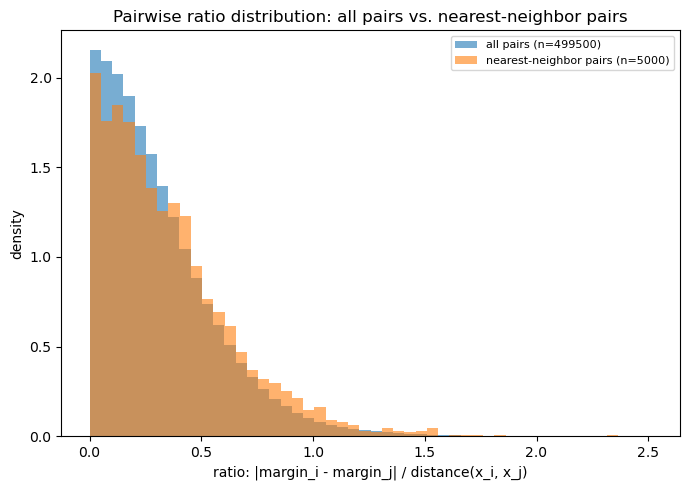

In [13]:
import numpy as np

all_pairs_ratio = ratio_dist_results["all_pairs_ratio"].numpy()
near_neighbor_ratio = ratio_dist_results["near_neighbor_ratio"].numpy()

print(f"{'':22s}{'shape':>12}{'min':>10}{'max':>10}{'mean':>10}{'median':>10}{'std':>10}")
for label, arr in [("all pairs", all_pairs_ratio), ("near-neighbour pairs", near_neighbor_ratio)]:
    print(f"{label:22s}{str(arr.shape):>12}{arr.min():>10.4f}{arr.max():>10.4f}"
          f"{arr.mean():>10.4f}{np.median(arr):>10.4f}{arr.std():>10.4f}")

fig_ratio_dist = plots.plot_ratio_distribution(
    all_pairs_ratio, near_neighbor_ratio,
    save_path=run_experiment.RESULTS_DIR / "ratio_distribution.png")
display(fig_ratio_dist)

## Highest-ratio near-neighbour pairs

The specific image pairs driving the upper tail of the near-neighbour
distribution above -- two pixel-similar digits that this model's margin
treats very differently, the exact combination a local-Lipschitz
diagnostic is meant to flag. `plot_image_pairs` shows the top 6, with
each image's true and predicted label and the pair's ratio, deduplicated
so a mutual nearest-neighbour pair (which appears twice in the raw
near-neighbour index list, once in each direction) only counts once.

rank  true1  pred1  true2  pred2    ratio
   0      9      3      3      3   2.5161
   1      2      4      4      4   2.4476
   2      2      2      2      4   2.3611
   3      2      4      4      4   2.2388
   4      2      4      4      4   2.1899
   5      0      7      7      7   1.9209


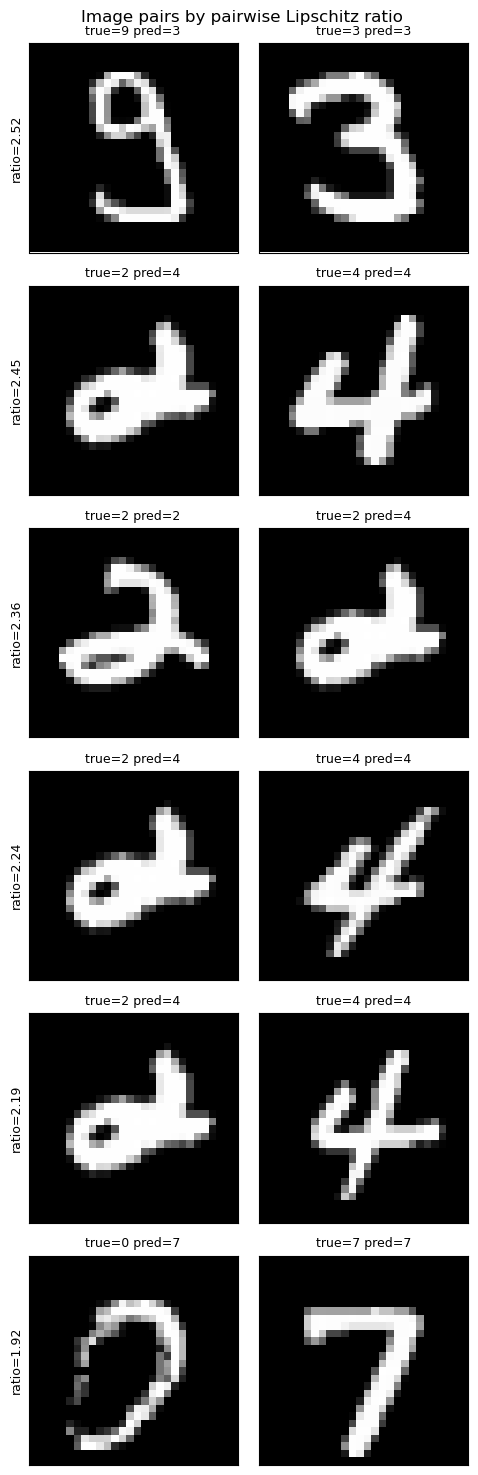

In [15]:
top_pairs = ratio_dist_results["top_near_neighbor_pairs"]

print(f"{'rank':>4}{'true1':>7}{'pred1':>7}{'true2':>7}{'pred2':>7}{'ratio':>9}")
for rank, (img1, img2, true1, pred1, true2, pred2, ratio) in enumerate(top_pairs):
    print(f"{rank:>4}{true1:>7}{pred1:>7}{true2:>7}{pred2:>7}{ratio:>9.4f}")

fig_top_pairs = plots.plot_image_pairs(
    top_pairs, save_path=run_experiment.RESULTS_DIR / "top_near_neighbor_pairs.png")
display(fig_top_pairs)

## Summary and status

See `README.md` in this folder for the full write-up, including the
actual measured numbers behind the plots above, the design decisions made
along the way (activation choice, pair-sampling strategy, the precision
vs. its inverse convention in the gradient-norm dual norm, why ridge
regularization was used before trying PCA truncation, how epsilon was
selected), and an honest account of what was and wasn't expected --
including that the three sub-methods agree much less closely here than
they did in Experiment 1's toy setting, and that this gap widens rather
than narrows under the Mahalanobis metric. The ratio-distribution
checkpoint above shows a similar pattern of modest, real effects rather
than dramatic ones: near-neighbour pairs show a modest but consistent
upward shift in ratio versus the full distribution, and the top pairs
correspond to classic visually-confusable digit pairs such as 2/4, 9/3,
and 0/7 -- currently checked for logistic regression + Euclidean distance
only, with the MLP, CNN, and Mahalanobis distance as the natural next
extension. Those results are reported as observed, not smoothed into a
cleaner story.

This is Experiment 2 of the Lipschitz-diagnostics project. Adversarial
examples, robustness mitigations, and Fashion-MNIST are explicitly out of
scope here and may be the subject of a later experiment.